# Análise de Marketing e CRM: Associados de uma Cooperativa Financeira

Análise do perfil e do comportamento de associados de uma cooperativa financeira, com foco em
marketing, segmentação e churn.

**Importante:** os dados deste notebook são **simulados**. As relações entre as variáveis foram
definidas na etapa de geração (seção 0), portanto os resultados demonstram o método de análise
e não representam fatos sobre uma instituição real.

## 0. Geração dos dados

**Pergunta de negócio:** como montar uma base de associados que se comporte de forma parecida
com uma base real, para que as análises de marketing façam sentido?

**Análise:** geração de 5.000 associados com semente fixa (`np.random.seed(42)`), para que o
resultado seja reproduzível. As variáveis não são sorteadas de forma independente: foram
criadas relações entre elas, sempre com ruído:

1. Associados do canal **Digital** são mais jovens e acessam mais o app.
2. O segmento **Agro** tem crédito rural com muito mais frequência.
3. **Pessoa Jurídica** tem saldo médio em conta corrente maior.
4. Quanto maior a **idade**, maior a chance de ter previdência e maior o valor investido.
5. Mais **produtos** tendem a gerar um NPS mais alto.
6. O **status** (Ativo, Inativo, Churned) é sorteado a partir de um score de risco que cresce
   com menos produtos, NPS baixo, pouco uso do app, poucas transações e menos tempo de associação.
7. Associados Churned e Inativos têm muitos dias sem acesso e pouco uso.
8. As **campanhas** respeitam a lógica do funil (abertas ≤ recebidas, convertidas ≤ abertas),
   com abertura maior para quem usa mais o app e conversão maior para quem veio por Indicação.

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

np.random.seed(42)
N = 5000


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def padronizar(x):
    return (x - x.mean()) / x.std()

### 0.1 Cadastro: identificação, localização, segmento, canal, idade e data de associação

In [2]:
associado_id = [f"A{i:05d}" for i in range(1, N + 1)]
nome = [f"Associado {i}" for i in range(1, N + 1)]

# Estado e cidade coerente com o estado
estados = ["RS", "SC", "PR", "SP", "MG", "RJ"]
estado = np.random.choice(estados, size=N, p=[0.35, 0.20, 0.15, 0.15, 0.10, 0.05])
cidades_por_estado = {
    "RS": (["Porto Alegre", "Caxias do Sul"], [0.6, 0.4]),
    "SC": (["Florianópolis", "Joinville"], [0.5, 0.5]),
    "PR": (["Curitiba", "Londrina"], [0.6, 0.4]),
    "SP": (["São Paulo"], [1.0]),
    "MG": (["Belo Horizonte"], [1.0]),
    "RJ": (["Rio de Janeiro"], [1.0]),
}
cidade = np.empty(N, dtype=object)
for uf, (cids, probs) in cidades_por_estado.items():
    mask = estado == uf
    cidade[mask] = np.random.choice(cids, size=mask.sum(), p=probs)

segmento = np.random.choice(["Pessoa Física", "Pessoa Jurídica", "Agro"], size=N, p=[0.60, 0.25, 0.15])
canal_aquisicao = np.random.choice(["Agência", "Digital", "Indicação", "Campanha"], size=N, p=[0.30, 0.35, 0.20, 0.15])
genero = np.random.choice(["M", "F"], size=N)

# Idade: quem entrou pelo canal Digital é mais jovem em média.
# Valores fora da faixa de 18 a 74 anos são sorteados de novo (distribuição truncada).
def sortear_idade(canais):
    return np.where(canais == "Digital",
                    np.random.normal(34, 10, len(canais)),
                    np.random.normal(46, 12, len(canais)))


idade = sortear_idade(canal_aquisicao)
fora_da_faixa = (idade < 17.5) | (idade >= 74.5)
while fora_da_faixa.any():
    idade[fora_da_faixa] = sortear_idade(canal_aquisicao[fora_da_faixa])
    fora_da_faixa = (idade < 17.5) | (idade >= 74.5)
idade = np.round(idade).astype(int)
idade_norm = (idade - 18) / 56

# Data de associação entre 2018-01-01 e 2025-09-30
inicio = pd.Timestamp("2018-01-01")
fim = pd.Timestamp("2025-09-30")
data_associacao = inicio + pd.to_timedelta(np.random.randint(0, (fim - inicio).days + 1, N), unit="D")

### 0.2 Produtos, uso, saldo e investimento

Uma variável auxiliar de **engajamento** (não salva na base) faz com que produtos, uso do app e
transações andem juntos, como acontece em bases reais.

Alguns associados ficam sem nenhum dos 6 produtos. Isso é esperado: numa cooperativa, a pessoa se torna associada ao integralizar a cota capital, que não faz parte desta lista, e pode nunca ter contratado outro produto.

In [3]:
engajamento = np.random.normal(0, 1, N)

# Posse de produtos
p_cc = sigmoid(np.where(segmento == "Pessoa Jurídica", 2.94, 1.73) + 0.6 * engajamento)
tem_conta_corrente = (np.random.rand(N) < p_cc).astype(int)
tem_cartao_credito = (np.random.rand(N) < sigmoid(-0.3 + 1.5 * engajamento + 1.0 * tem_conta_corrente)).astype(int)
tem_seguro = (np.random.rand(N) < sigmoid(-1.2 + 1.1 * engajamento)).astype(int)
tem_consorcio = (np.random.rand(N) < sigmoid(-2.3 + 1.0 * engajamento)).astype(int)
tem_previdencia = (np.random.rand(N) < sigmoid(-2.8 + 2.8 * idade_norm + 0.9 * engajamento)).astype(int)
tem_credito_rural = (np.random.rand(N) < np.where(segmento == "Agro", 0.70, 0.03)).astype(int)

qtd_produtos = (tem_conta_corrente + tem_cartao_credito + tem_seguro
                + tem_consorcio + tem_previdencia + tem_credito_rural)

# Uso do app e transações (valores base, antes do efeito do status)
lambda_app = (6 * np.exp(0.45 * engajamento)
              * np.where(canal_aquisicao == "Digital", 1.7, 1.0)
              * (1.3 - 0.6 * idade_norm))
acessos_base = np.random.poisson(lambda_app)

fator_seg_trans = np.select([segmento == "Pessoa Jurídica", segmento == "Agro"], [1.8, 1.3], 1.0)
lambda_trans = 25 * np.exp(0.4 * engajamento) * fator_seg_trans * (0.5 + 0.5 * tem_conta_corrente)
transacoes_base = np.random.poisson(lambda_trans)

# Saldo médio em conta corrente: maior para Pessoa Jurídica (zero para quem não tem conta)
media_log_saldo = np.select([segmento == "Pessoa Jurídica", segmento == "Agro"], [9.4, 8.8], 8.0)
saldo_medio_cc = np.round(np.random.lognormal(media_log_saldo, 0.8) * tem_conta_corrente, 2)

# Valor investido: cresce com a idade; parte da base não investe
tem_investimento = np.random.rand(N) < sigmoid(-0.3 + 1.5 * idade_norm + 0.3 * engajamento)
valor_investido = np.round(np.random.lognormal(8.5 + 1.8 * idade_norm, 1.0) * tem_investimento, 2)

# NPS: mais produtos tende a um NPS mais alto
nps_score = np.clip(np.round(6.5 + 0.75 * qtd_produtos + np.random.normal(0, 1.9, N)), 0, 10).astype(int)

### 0.3 Status do associado a partir de um score de risco

O score de risco combina menos produtos, NPS baixo, pouco uso do app, poucas transações e menos
tempo de associação (associados recentes ainda não criaram vínculo), mais um ruído aleatório. A partir dele são sorteadas as probabilidades de Churned e de Inativo,
calibradas para chegar perto de 70% Ativo, 15% Inativo e 15% Churned.

In [4]:
anos_associacao = (fim - data_associacao).days.to_numpy() / 365.25

risco = (-0.8 * padronizar(qtd_produtos)
         - 0.8 * padronizar(nps_score)
         - 0.7 * padronizar(np.log1p(acessos_base))
         - 0.6 * padronizar(np.log1p(transacoes_base))
         - 0.5 * padronizar(anos_associacao)
         + np.random.normal(0, 0.9, N))
risco = padronizar(risco)

p_churn = sigmoid(-2.5 + 1.6 * risco)
p_inativo = sigmoid(-1.55 + 0.7 * risco)
sorteio = np.random.rand(N)
status = np.where(sorteio < p_churn, "Churned",
                  np.where(sorteio < p_churn + (1 - p_churn) * p_inativo, "Inativo", "Ativo"))

# Coerência com o status: Churned e Inativo usam bem menos e estão há mais tempo sem acessar
fator_uso = np.select([status == "Churned", status == "Inativo"], [0.10, 0.35], 1.0)
acessos_app_mes = np.random.binomial(acessos_base, fator_uso)
transacoes_ultimo_trimestre = np.random.binomial(transacoes_base, fator_uso)
dias_desde_ultimo_acesso = np.select(
    [status == "Churned", status == "Inativo"],
    [np.random.normal(220, 60, N), np.random.normal(110, 35, N)],
    np.random.exponential(12, N))
dias_desde_ultimo_acesso = np.clip(np.round(dias_desde_ultimo_acesso), 0, 365).astype(int)

### 0.4 Campanhas de marketing

In [5]:
campanhas_recebidas = np.random.poisson(6, N)

# Abertura maior para quem acessa mais o app
campanhas_abertas = np.random.binomial(campanhas_recebidas, sigmoid(-1.3 + 0.12 * acessos_app_mes))

# Conversão um pouco maior para quem veio por Indicação
campanhas_convertidas = np.random.binomial(campanhas_abertas, np.where(canal_aquisicao == "Indicação", 0.22, 0.14))

### 0.5 Montagem da base, variáveis derivadas e exportação

In [6]:
df = pd.DataFrame({
    "associado_id": associado_id,
    "nome": nome,
    "idade": idade,
    "genero": genero,
    "estado": estado,
    "cidade": cidade,
    "segmento": segmento,
    "data_associacao": data_associacao.strftime("%Y-%m-%d"),
    "canal_aquisicao": canal_aquisicao,
    "tem_conta_corrente": tem_conta_corrente,
    "tem_cartao_credito": tem_cartao_credito,
    "tem_seguro": tem_seguro,
    "tem_consorcio": tem_consorcio,
    "tem_previdencia": tem_previdencia,
    "tem_credito_rural": tem_credito_rural,
    "transacoes_ultimo_trimestre": transacoes_ultimo_trimestre,
    "saldo_medio_cc": saldo_medio_cc,
    "valor_investido": valor_investido,
    "nps_score": nps_score,
    "dias_desde_ultimo_acesso": dias_desde_ultimo_acesso,
    "acessos_app_mes": acessos_app_mes,
    "campanhas_recebidas": campanhas_recebidas,
    "campanhas_abertas": campanhas_abertas,
    "campanhas_convertidas": campanhas_convertidas,
    "status": status,
})

colunas_produtos = ["tem_conta_corrente", "tem_cartao_credito", "tem_seguro",
                    "tem_consorcio", "tem_previdencia", "tem_credito_rural"]
df["qtd_produtos"] = df[colunas_produtos].sum(axis=1)
df["taxa_abertura_campanha"] = np.where(
    df["campanhas_recebidas"] > 0,
    df["campanhas_abertas"] / df["campanhas_recebidas"].replace(0, 1), 0).round(2)
df["taxa_conversao_campanha"] = np.where(
    df["campanhas_abertas"] > 0,
    df["campanhas_convertidas"] / df["campanhas_abertas"].replace(0, 1), 0).round(2)

# utf-8-sig para que os acentos também apareçam corretamente ao abrir o arquivo no Excel
df.to_csv("../data/associados_simulados.csv", index=False, encoding="utf-8-sig")
df.head()

,associado_id,nome,idade,genero,estado,cidade,segmento,data_associacao,canal_aquisicao,tem_conta_corrente,tem_cartao_credito,tem_seguro,tem_consorcio,tem_previdencia,tem_credito_rural,transacoes_ultimo_trimestre,saldo_medio_cc,valor_investido,nps_score,dias_desde_ultimo_acesso,acessos_app_mes,campanhas_recebidas,campanhas_abertas,campanhas_convertidas,status,qtd_produtos,taxa_abertura_campanha,taxa_conversao_campanha
0,A00001,Associado 1,25,F,SC,Joinville,Pessoa Física,2021-03-28,Digital,1,1,0,1,1,0,38,3019.57,10542.52,4,19,17,5,3,2,Ativo,4,0.60,0.67
1,A00002,Associado 2,40,F,RJ,Rio de Janeiro,Pessoa Física,2020-03-02,Indicação,1,0,0,0,0,0,15,1549.70,4178.16,9,21,5,9,3,2,Ativo,1,0.33,0.67
2,A00003,Associado 3,39,F,SP,São Paulo,Pessoa Física,2023-01-13,Digital,1,1,0,0,0,0,5,2031.71,0.00,6,105,2,5,3,0,Inativo,2,0.60,0.00
3,A00004,Associado 4,31,M,PR,Curitiba,Pessoa Jurídica,2022-04-16,Agência,1,1,1,1,0,0,22,5088.55,4038.78,9,86,3,5,2,0,Inativo,4,0.40,0.00
4,A00005,Associado 5,39,M,RS,Porto Alegre,Pessoa Física,2023-11-07,Agência,1,1,1,1,1,0,4,2038.93,0.00,10,122,2,3,0,0,Inativo,5,0.00,0.00


### 0.6 Validação da base gerada

In [7]:
print(f"Registros: {df.shape[0]} | Colunas: {df.shape[1]}")
print()
print("Proporção de status (%):")
print((df["status"].value_counts(normalize=True) * 100).round(1))
print()

# Checagens de consistência do funil de campanhas
assert (df["campanhas_abertas"] <= df["campanhas_recebidas"]).all()
assert (df["campanhas_convertidas"] <= df["campanhas_abertas"]).all()

comparativo_status = (
    df.groupby("status")[["qtd_produtos", "nps_score", "acessos_app_mes", "dias_desde_ultimo_acesso"]]
    .mean()
    .reindex(["Ativo", "Inativo", "Churned"])
    .round(2)
)
comparativo_status.columns = ["Média de produtos", "NPS médio", "Acessos ao app/mês", "Dias sem acesso"]
comparativo_status

Registros: 5000 | Colunas: 28

Proporção de status (%):
status
Ativo      70.5
Inativo    14.9
Churned    14.6
Name: proportion, dtype: float64



,Média de produtos,NPS médio,Acessos ao app/mês,Dias sem acesso
status,,,,
Ativo,2.44,8.27,9.68,12.08
Inativo,1.93,7.55,2.72,111.30
Churned,1.31,6.69,0.54,221.70


**O que o resultado mostra:** a base tem 5.000 associados e 28 colunas, com cerca de 70% Ativos,
15% Inativos e 15% Churned. A tabela confirma que as relações definidas na geração aparecem nos
dados: do Ativo para o Churned, a média de produtos cai (2,4 para 1,3), o NPS médio cai
(8,3 para 6,7), os acessos ao app praticamente zeram (9,7 para 0,5) e os dias sem acesso sobem
de cerca de 12 para mais de 200. O grupo Inativo fica no meio do caminho em todos os indicadores.

## Configuração dos gráficos

Padrão visual usado em todos os gráficos: fundo claro, grade discreta, uma cor principal para
séries únicas, cores de estado para o status do associado e todos os gráficos salvos em `assets/`.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 10,
})

AZUL = "#2a78d6"
LARANJA = "#eb6834"
VERMELHO = "#e34948"
TEXTO_SECUNDARIO = "#52514e"
CORES_STATUS = {"Ativo": "#0ca30c", "Inativo": "#fab219", "Churned": "#d03b3b"}
ORDEM_STATUS = ["Ativo", "Inativo", "Churned"]
RAMPA_AZUL = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
CMAP_DIVERGENTE = LinearSegmentedColormap.from_list("divergente", [VERMELHO, "#f0efec", AZUL])


def fmt_num(valor, casas=1):
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def fmt_pct(valor, casas=1):
    return fmt_num(valor, casas) + "%"


def rotular(ax, barras, rotulos):
    ax.bar_label(barras, labels=rotulos, padding=3, color=TEXTO_SECUNDARIO, fontsize=9,
                 bbox={"facecolor": "#fcfcfb", "edgecolor": "none", "pad": 1})


def salvar(fig, nome):
    fig.tight_layout()
    fig.savefig(f"../assets/{nome}.png", dpi=150, bbox_inches="tight")
    plt.show()


ativos = df[df["status"] == "Ativo"]

## 1. Visão geral da base

**Pergunta de negócio:** quem são os associados da cooperativa? Quantos estão ativos, onde estão,
de quais segmentos e canais vieram, qual a faixa de idade e como a base cresceu ao longo do tempo?

**Análise:** contagem por status, distribuição por estado, segmento e canal de aquisição,
histograma de idade e evolução das novas associações por ano e por mês.

### 1.1 Associados por status

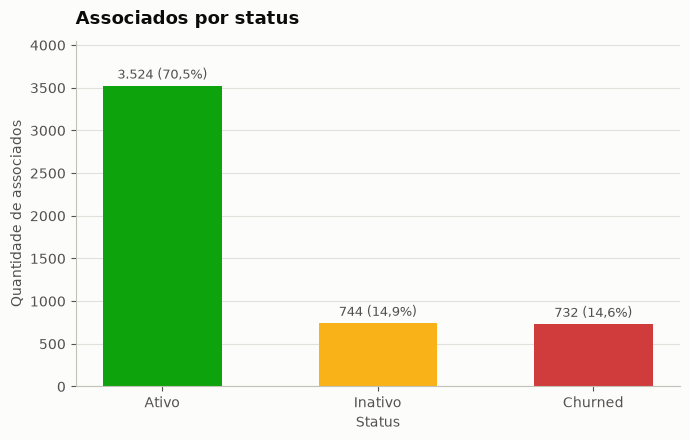

In [9]:
qtd_status = df["status"].value_counts().reindex(ORDEM_STATUS)
pct_status = qtd_status / len(df) * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(qtd_status.index, qtd_status.values,
                color=[CORES_STATUS[s] for s in ORDEM_STATUS], width=0.55)
rotular(ax, barras, [f"{fmt_num(n, 0)} ({fmt_pct(p)})" for n, p in zip(qtd_status, pct_status)])
ax.set_title("Associados por status")
ax.set_xlabel("Status")
ax.set_ylabel("Quantidade de associados")
ax.set_ylim(0, qtd_status.max() * 1.15)
ax.grid(axis="x", visible=False)
salvar(fig, "01_associados_por_status")

### 1.2 Distribuição por estado, segmento e canal de aquisição

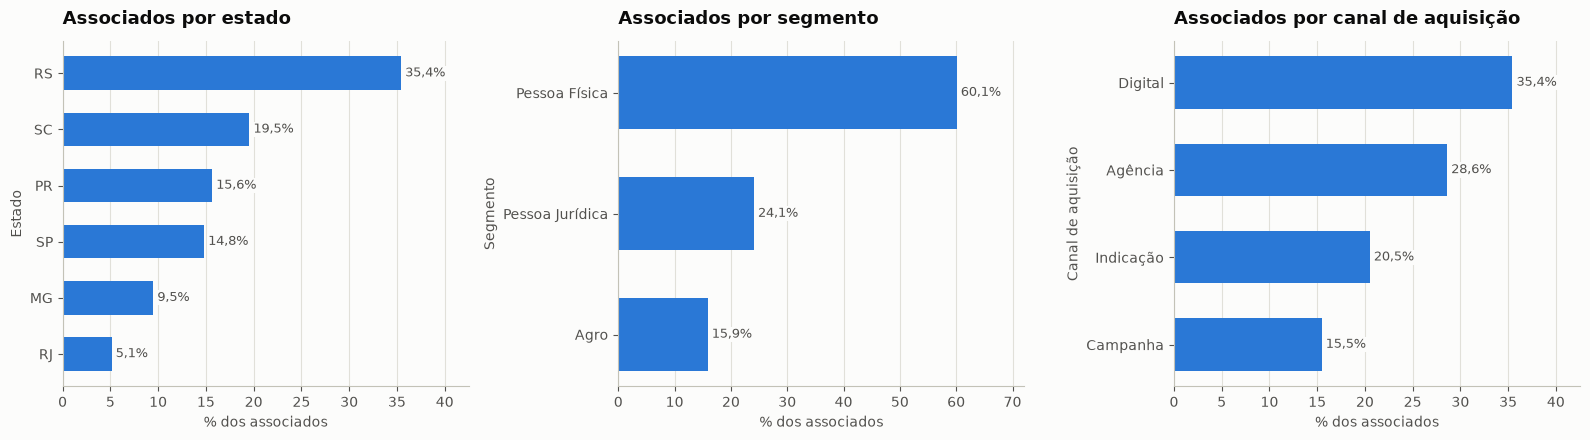

Associados por cidade:
cidade
Porto Alegre      1089
São Paulo          740
Caxias do Sul      682
Florianópolis      504
Curitiba           494
Belo Horizonte     474
Joinville          473
Londrina           288
Rio de Janeiro     256
Name: count, dtype: int64


In [10]:
dimensoes = [("estado", "Estado"), ("segmento", "Segmento"), ("canal_aquisicao", "Canal de aquisição")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (coluna, nome) in zip(axes, dimensoes):
    distribuicao = df[coluna].value_counts(normalize=True).sort_values() * 100
    barras = ax.barh(distribuicao.index, distribuicao.values, color=AZUL, height=0.6)
    rotular(ax, barras, [fmt_pct(v) for v in distribuicao.values])
    ax.set_title(f"Associados por {nome.lower()}")
    ax.set_xlabel("% dos associados")
    ax.set_ylabel(nome)
    ax.set_xlim(0, distribuicao.max() * 1.2)
    ax.grid(axis="y", visible=False)
salvar(fig, "02_distribuicao_estado_segmento_canal")

print("Associados por cidade:")
print(df["cidade"].value_counts())

### 1.3 Distribuição de idade

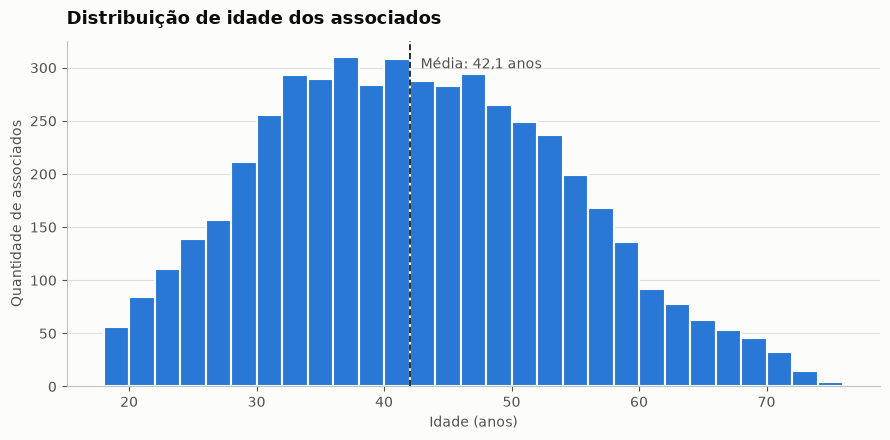

Idade por canal de aquisição:
                 média  mediana
canal_aquisicao                
Agência           45.9     46.0
Campanha          46.3     46.0
Digital           35.0     34.0
Indicação         45.8     46.0


In [11]:
media_idade = df["idade"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df["idade"], bins=range(18, 77, 2), color=AZUL, edgecolor="#fcfcfb", linewidth=1.5)
ax.axvline(media_idade, color="#0b0b0b", linestyle="--", linewidth=1.2)
ax.text(media_idade + 0.8, ax.get_ylim()[1] * 0.92, f"Média: {fmt_num(media_idade)} anos", color=TEXTO_SECUNDARIO)
ax.set_title("Distribuição de idade dos associados")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Quantidade de associados")
ax.grid(axis="x", visible=False)
salvar(fig, "03_histograma_idade")

print("Idade por canal de aquisição:")
print(df.groupby("canal_aquisicao")["idade"].agg(["mean", "median"]).round(1).rename(columns={"mean": "média", "median": "mediana"}))

### 1.4 Novas associações por ano e por mês

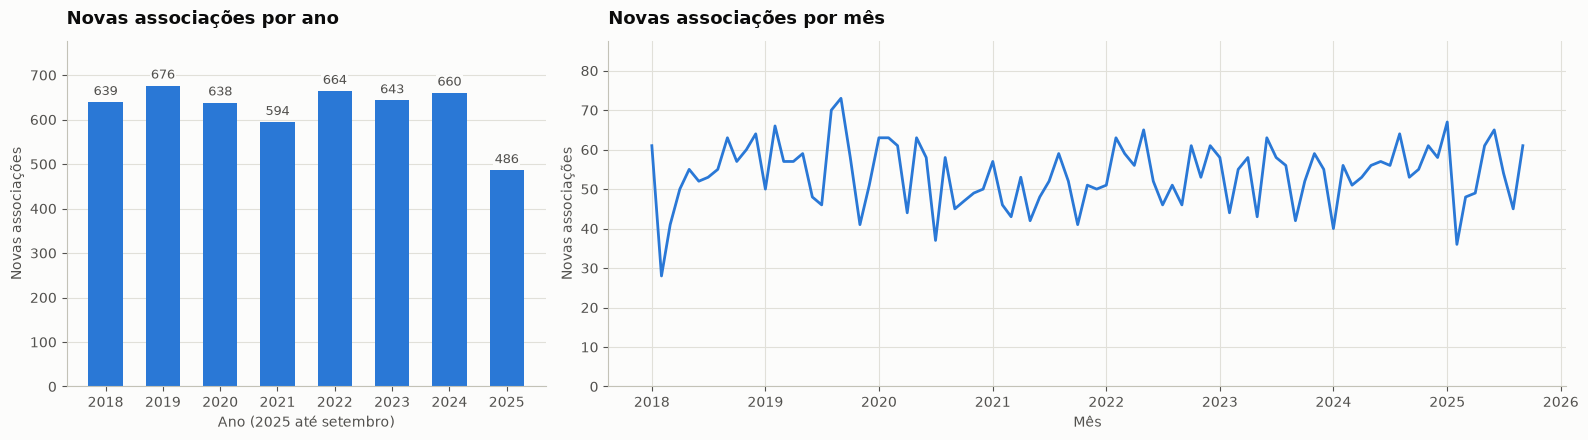

Média mensal de novas associações: 53,8


In [12]:
datas = pd.to_datetime(df["data_associacao"])
por_ano = datas.dt.year.value_counts().sort_index()
por_mes = datas.dt.to_period("M").value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [1, 2]})

ax = axes[0]
barras = ax.bar(por_ano.index.astype(str), por_ano.values, color=AZUL, width=0.6)
rotular(ax, barras, [fmt_num(v, 0) for v in por_ano.values])
ax.set_title("Novas associações por ano")
ax.set_xlabel("Ano (2025 até setembro)")
ax.set_ylabel("Novas associações")
ax.set_ylim(0, por_ano.max() * 1.15)
ax.grid(axis="x", visible=False)

ax = axes[1]
ax.plot(por_mes.index.to_timestamp(), por_mes.values, color=AZUL, linewidth=2)
ax.set_title("Novas associações por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Novas associações")
ax.set_ylim(0, por_mes.max() * 1.2)

salvar(fig, "04_novas_associacoes")

print(f"Média mensal de novas associações: {fmt_num(por_mes.mean())}")

**O que o resultado mostra:**
- **70,5%** dos 5.000 associados estão ativos, 14,9% estão inativos e 14,6% saíram (Churned).
- A base é concentrada no Sul: **RS tem 35,4%** dos associados e, somando SC e PR, a região chega
  a cerca de 70%. Porto Alegre é a cidade com mais associados.
- **Pessoa Física** é 60,1% da base, seguida de Pessoa Jurídica (24,1%) e Agro (15,9%).
- **Digital** é o principal canal de entrada (35,4%) e traz um público bem mais jovem:
  idade média de 35 anos, contra cerca de 46 nos demais canais. A idade média geral é 42,1 anos.
- As novas associações são estáveis ao longo do tempo, com cerca de 650 por ano e média de
  54 por mês. Em 2025 (até setembro) o ritmo se mantém.

## 2. Produtos e cross-sell

**Pergunta de negócio:** quais produtos os associados já têm, quantos produtos cada um tem em
média, quais produtos costumam aparecer juntos e onde está a oportunidade de venda cruzada?

**Análise:** penetração de cada produto, distribuição da quantidade de produtos por associado,
correlação entre a posse dos produtos e o tamanho do público de associados ativos com conta
corrente e sem cartão de crédito.

### 2.1 Penetração dos produtos

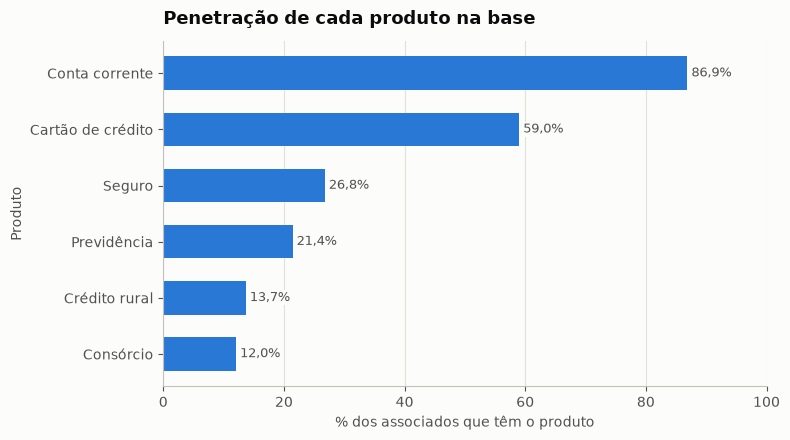

Penetração do crédito rural por segmento (%):
segmento
Agro               69.1
Pessoa Física       3.1
Pessoa Jurídica     3.6
Name: tem_credito_rural, dtype: float64


In [13]:
nomes_produtos = {
    "tem_conta_corrente": "Conta corrente",
    "tem_cartao_credito": "Cartão de crédito",
    "tem_seguro": "Seguro",
    "tem_consorcio": "Consórcio",
    "tem_previdencia": "Previdência",
    "tem_credito_rural": "Crédito rural",
}
penetracao = (df[colunas_produtos].mean() * 100).rename(nomes_produtos).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.barh(penetracao.index, penetracao.values, color=AZUL, height=0.6)
rotular(ax, barras, [fmt_pct(v) for v in penetracao.values])
ax.set_title("Penetração de cada produto na base")
ax.set_xlabel("% dos associados que têm o produto")
ax.set_ylabel("Produto")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
salvar(fig, "05_penetracao_produtos")

print("Penetração do crédito rural por segmento (%):")
print((df.groupby("segmento")["tem_credito_rural"].mean() * 100).round(1))

### 2.2 Quantidade de produtos por associado

Média de produtos por associado: 2,20

Média de produtos por segmento e por status:
segmento
Agro               2.73
Pessoa Física      2.05
Pessoa Jurídica    2.21
Name: qtd_produtos, dtype: float64
status
Ativo      2.44
Inativo    1.93
Churned    1.31
Name: qtd_produtos, dtype: float64


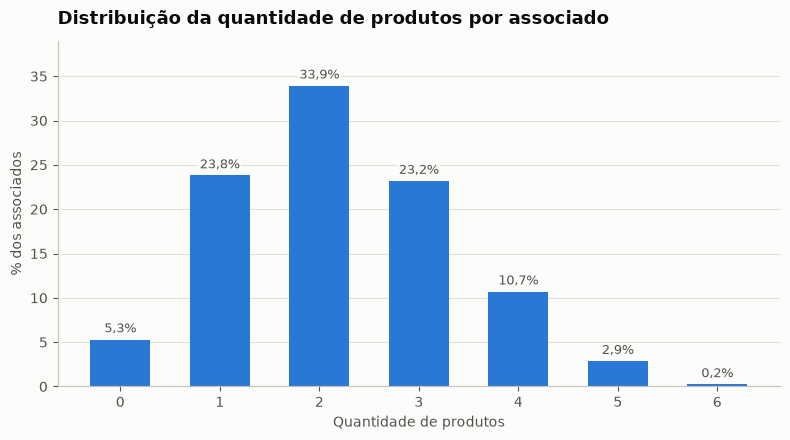

In [14]:
print(f"Média de produtos por associado: {fmt_num(df['qtd_produtos'].mean(), 2)}")
print()
print("Média de produtos por segmento e por status:")
print(df.groupby("segmento")["qtd_produtos"].mean().round(2))
print(df.groupby("status")["qtd_produtos"].mean().reindex(ORDEM_STATUS).round(2))

dist_produtos = df["qtd_produtos"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(dist_produtos.index.astype(str), dist_produtos.values, color=AZUL, width=0.6)
rotular(ax, barras, [fmt_pct(v) for v in dist_produtos.values])
ax.set_title("Distribuição da quantidade de produtos por associado")
ax.set_xlabel("Quantidade de produtos")
ax.set_ylabel("% dos associados")
ax.set_ylim(0, dist_produtos.max() * 1.15)
ax.grid(axis="x", visible=False)
salvar(fig, "06_distribuicao_qtd_produtos")

### 2.3 Correlação entre a posse de produtos

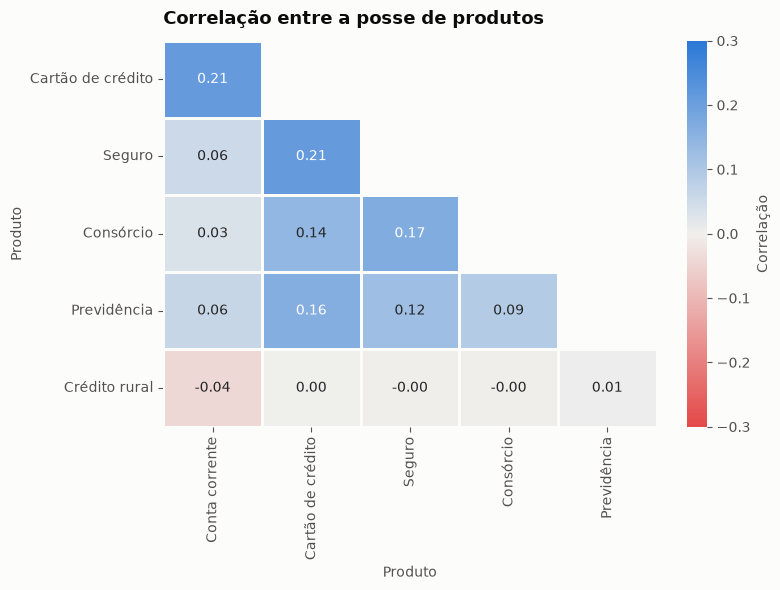

In [15]:
correlacao = df[colunas_produtos].rename(columns=nomes_produtos).corr()
correlacao_triangulo = correlacao.iloc[1:, :-1]
mascara = np.triu(np.ones_like(correlacao_triangulo, dtype=bool), k=1)
limite = np.ceil(correlacao_triangulo.where(~mascara).abs().max().max() * 10) / 10

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlacao_triangulo, mask=mascara, cmap=CMAP_DIVERGENTE, vmin=-limite, vmax=limite,
            annot=True, fmt=".2f", linewidths=2, linecolor="#fcfcfb",
            cbar_kws={"label": "Correlação"}, ax=ax)
ax.set_title("Correlação entre a posse de produtos")
ax.set_xlabel("Produto")
ax.set_ylabel("Produto")
ax.tick_params(axis="y", rotation=0)
ax.grid(False)
salvar(fig, "07_heatmap_correlacao_produtos")

### 2.4 Oportunidade: associados ativos com conta corrente e sem cartão de crédito

Associados ativos: 3.524
Ativos com conta corrente: 3.197
Ativos com conta corrente e sem cartão: 977 (30,6% dos ativos com conta)


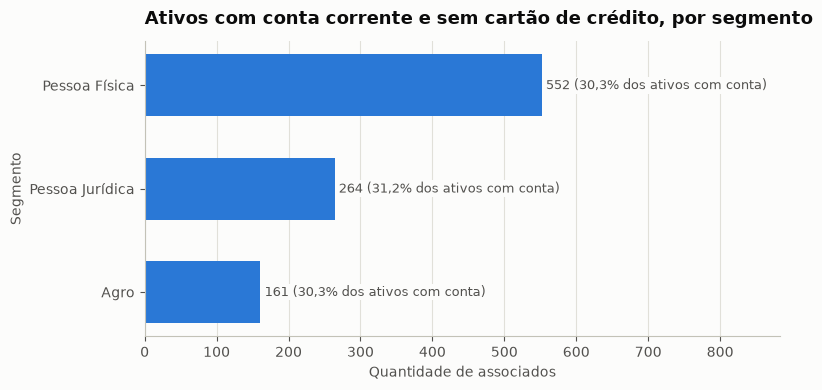

In [16]:
ativos_com_conta = ativos[ativos["tem_conta_corrente"] == 1]
oportunidade_cartao = ativos_com_conta[ativos_com_conta["tem_cartao_credito"] == 0]

print(f"Associados ativos: {fmt_num(len(ativos), 0)}")
print(f"Ativos com conta corrente: {fmt_num(len(ativos_com_conta), 0)}")
print(f"Ativos com conta corrente e sem cartão: {fmt_num(len(oportunidade_cartao), 0)} "
      f"({fmt_pct(len(oportunidade_cartao) / len(ativos_com_conta) * 100)} dos ativos com conta)")

oportunidade_segmento = pd.DataFrame({
    "associados": oportunidade_cartao.groupby("segmento").size(),
    "pct_ativos_com_conta": (oportunidade_cartao.groupby("segmento").size()
                             / ativos_com_conta.groupby("segmento").size() * 100),
}).sort_values("associados")

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(oportunidade_segmento.index, oportunidade_segmento["associados"], color=AZUL, height=0.6)
rotular(ax, barras, [f"{fmt_num(n, 0)} ({fmt_pct(p)} dos ativos com conta)"
                     for n, p in zip(oportunidade_segmento["associados"], oportunidade_segmento["pct_ativos_com_conta"])])
ax.set_title("Ativos com conta corrente e sem cartão de crédito, por segmento")
ax.set_xlabel("Quantidade de associados")
ax.set_ylabel("Segmento")
ax.set_xlim(0, oportunidade_segmento["associados"].max() * 1.6)
ax.grid(axis="y", visible=False)
salvar(fig, "08_oportunidade_cartao_por_segmento")

**O que o resultado mostra:**
- Conta corrente (86,9%) e cartão de crédito (59,0%) são os produtos de entrada. Seguro (26,8%),
  previdência (21,4%), crédito rural (13,7%) e consórcio (12,0%) têm penetração bem menor.
- O crédito rural é praticamente exclusivo do segmento Agro (69,1% dos associados Agro têm o
  produto, contra cerca de 3% nos demais), o que faz do Agro o segmento com mais produtos
  por associado (2,73, contra 2,20 na média geral).
- A média é de **2,20 produtos por associado** e a maior parte da base tem de 1 a 3 produtos.
- O cartão de crédito é o produto mais conectado aos demais: as maiores correlações são dele com
  conta corrente e com seguro (0,21 nos dois casos). Seguro e consórcio também andam juntos (0,17).
  Quem já tem cartão é um bom público para ofertas de seguro e consórcio. O crédito rural não se
  relaciona com os outros produtos, porque depende do segmento.
- **977 associados ativos** têm conta corrente e não têm cartão de crédito (30,6% dos ativos com
  conta). É um público já engajado e pronto para uma campanha de cartão, com 552 associados em
  Pessoa Física, 264 em Pessoa Jurídica e 161 no Agro.

## 3. Segmentação RFV (associados ativos)

**Pergunta de negócio:** entre os associados ativos, quem são os mais valiosos e quem dá sinais
de que pode se afastar?

**Análise:** segmentação RFV com três dimensões:
- **Recência:** `dias_desde_ultimo_acesso`, invertida (quanto menos dias, maior o score);
- **Frequência:** `transacoes_ultimo_trimestre`;
- **Valor:** `saldo_medio_cc`.

Cada dimensão é normalizada entre 0 e 1 com `MinMaxScaler` e o score RFV é a média das três.
Como o saldo é muito assimétrico, o score fica concentrado numa faixa estreita. Por isso, as
classes usam os **quartis do score** como limites (cerca de 25% dos ativos em cada uma):
Em risco, Atenção, Potencial e Premium.

In [17]:
rfv = ativos[["associado_id", "dias_desde_ultimo_acesso", "transacoes_ultimo_trimestre",
              "saldo_medio_cc", "valor_investido"]].copy()

normalizado = MinMaxScaler().fit_transform(
    rfv[["dias_desde_ultimo_acesso", "transacoes_ultimo_trimestre", "saldo_medio_cc"]])
rfv["score_recencia"] = 1 - normalizado[:, 0]
rfv["score_frequencia"] = normalizado[:, 1]
rfv["score_valor"] = normalizado[:, 2]
rfv["score_rfv"] = rfv[["score_recencia", "score_frequencia", "score_valor"]].mean(axis=1)

ORDEM_RFV = ["Em risco", "Atenção", "Potencial", "Premium"]
limites_rfv = rfv["score_rfv"].quantile([0, 0.25, 0.5, 0.75, 1]).values
rfv["segmento_rfv"] = pd.cut(rfv["score_rfv"], bins=limites_rfv, labels=ORDEM_RFV, include_lowest=True)

print("Limites do score RFV (quartis):", np.round(limites_rfv, 3))

colunas_score = ["score_recencia", "score_frequencia", "score_valor", "score_rfv"]
rfv[colunas_score] = rfv[colunas_score].round(4)
rfv[["associado_id", *colunas_score, "segmento_rfv", "saldo_medio_cc", "valor_investido"]].to_csv(
    "../data/associados_rfv.csv", index=False, encoding="utf-8-sig")

resumo_rfv = rfv.groupby("segmento_rfv", observed=True).agg(
    associados=("associado_id", "count"),
    dias_sem_acesso=("dias_desde_ultimo_acesso", "mean"),
    transacoes=("transacoes_ultimo_trimestre", "mean"),
    saldo_medio_cc=("saldo_medio_cc", "mean"),
    valor_investido=("valor_investido", "mean"),
    score_rfv=("score_rfv", "mean"),
).round(2)
resumo_rfv

Limites do score RFV (quartis): [0.038 0.346 0.38  0.419 0.712]


,associados,dias_sem_acesso,transacoes,saldo_medio_cc,valor_investido,score_rfv
segmento_rfv,,,,,,
Em risco,881,23.81,21.75,3030.31,11960.03,0.31
Atenção,881,10.03,26.18,4077.80,9826.39,0.36
Potencial,881,7.40,35.85,6201.05,11316.30,0.40
Premium,881,7.08,56.20,16601.00,11888.77,0.47


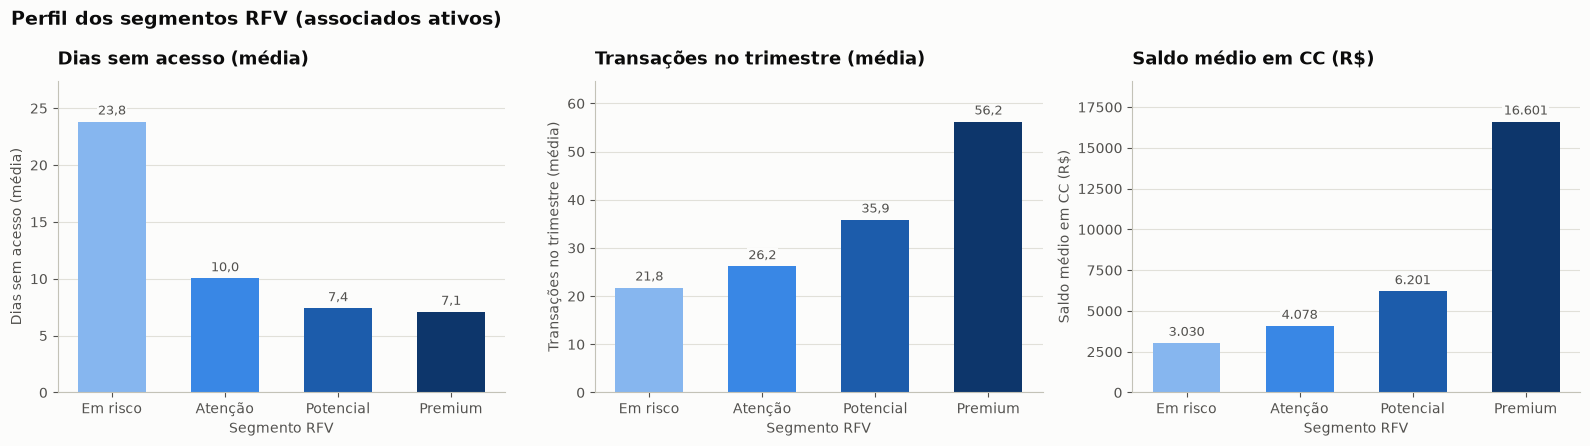

In [18]:
metricas_rfv = [
    ("dias_sem_acesso", "Dias sem acesso (média)"),
    ("transacoes", "Transações no trimestre (média)"),
    ("saldo_medio_cc", "Saldo médio em CC (R$)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (coluna, nome) in zip(axes, metricas_rfv):
    valores = resumo_rfv[coluna]
    barras = ax.bar(valores.index.astype(str), valores.values, color=RAMPA_AZUL, width=0.6)
    casas = 0 if coluna == "saldo_medio_cc" else 1
    rotular(ax, barras, [fmt_num(v, casas) for v in valores.values])
    ax.set_title(nome)
    ax.set_xlabel("Segmento RFV")
    ax.set_ylabel(nome)
    ax.set_ylim(0, valores.max() * 1.15)
    ax.grid(axis="x", visible=False)
fig.suptitle("Perfil dos segmentos RFV (associados ativos)", x=0.01, ha="left", fontsize=14, fontweight="bold")
salvar(fig, "09_perfil_segmentos_rfv")

**O que o resultado mostra:**
- Cada classe reúne 881 associados ativos (um quarto da base ativa).
- O **Premium** se destaca em frequência e valor: 56,2 transações no trimestre e saldo médio de
  cerca de R$ 16,6 mil, mais de 5 vezes o saldo do grupo Em risco (cerca de R$ 3,0 mil).
- O grupo **Em risco** ainda é ativo, mas já acumula 24 dias sem acesso em média, contra 7 a 10 dias
  nas outras classes. É o público certo para ações de reengajamento antes que ele vire Inativo.
- **Potencial** e **Atenção** têm recência parecida com a do Premium, mas movimentam e guardam
  menos: são candidatos a campanhas para aumentar o uso e o saldo.
- O valor investido quase não muda entre as classes (de R$ 9,8 mil a R$ 12,0 mil), porque ele não
  faz parte do score. Isso indica espaço para ofertas de investimento também fora do Premium.
- A classificação completa foi exportada em `data/associados_rfv.csv`.

## 4. NPS

**Pergunta de negócio:** os associados recomendariam a cooperativa? A satisfação muda entre
segmentos, estados e canais? Ela tem relação com a quantidade de produtos e com o uso do app?

**Análise:** classificação em Promotores (nota 9 ou 10), Neutros (7 ou 8) e Detratores (0 a 6).
NPS = % de promotores menos % de detratores, calculado para a base toda e por grupo.

In [19]:
def calcular_nps(notas):
    return ((notas >= 9).mean() - (notas <= 6).mean()) * 100


categoria_nps = pd.cut(df["nps_score"], bins=[-1, 6, 8, 10], labels=["Detrator", "Neutro", "Promotor"])
print("Distribuição das categorias de NPS (%):")
print((categoria_nps.value_counts(normalize=True).reindex(["Promotor", "Neutro", "Detrator"]) * 100).round(1))
print()
nps_geral = calcular_nps(df["nps_score"])
print(f"NPS geral: {fmt_num(nps_geral)}")

Distribuição das categorias de NPS (%):
nps_score
Promotor    43.2
Neutro      35.4
Detrator    21.4
Name: proportion, dtype: float64

NPS geral: 21,8


### 4.1 NPS por segmento, estado e canal de aquisição

NPS por estado: {'RS': 18.5, 'PR': 20.1, 'SP': 20.9, 'SC': 24.3, 'RJ': 27.7, 'MG': 30.0}
NPS por segmento: {'Pessoa Física': 17.7, 'Pessoa Jurídica': 20.2, 'Agro': 39.5}
NPS por canal de aquisição: {'Digital': 17.6, 'Agência': 23.2, 'Indicação': 24.5, 'Campanha': 25.2}


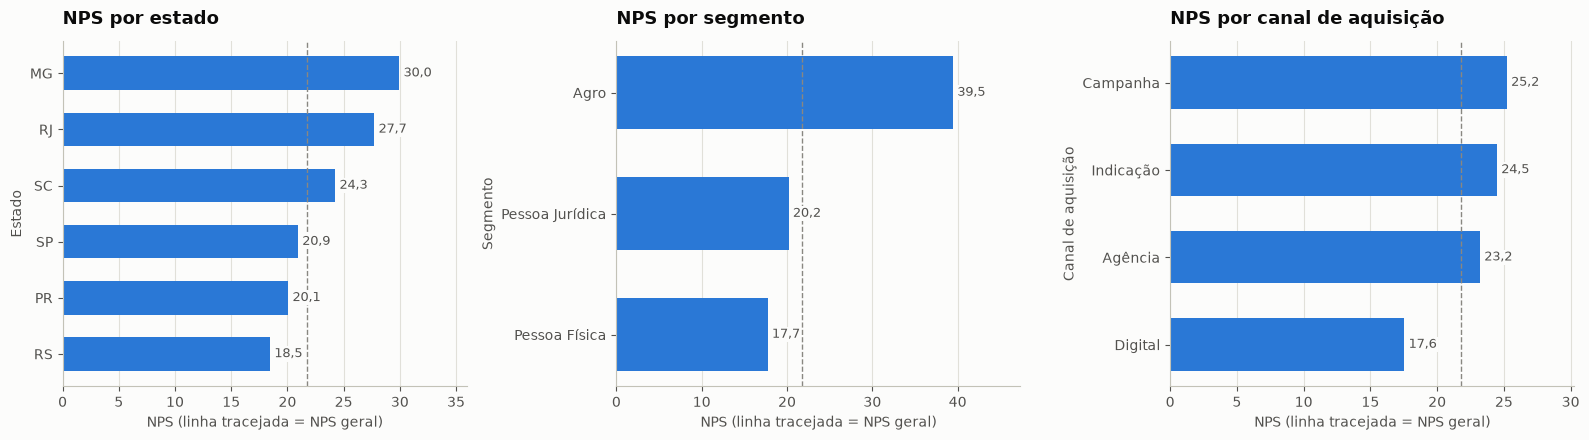

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (coluna, nome) in zip(axes, dimensoes):
    nps_grupo = df.groupby(coluna)["nps_score"].agg(calcular_nps).sort_values()
    barras = ax.barh(nps_grupo.index, nps_grupo.values, color=AZUL, height=0.6)
    rotular(ax, barras, [fmt_num(v) for v in nps_grupo.values])
    ax.axvline(nps_geral, color="#898781", linestyle="--", linewidth=1, zorder=1)
    ax.set_title(f"NPS por {nome.lower()}")
    ax.set_xlabel("NPS (linha tracejada = NPS geral)")
    ax.set_ylabel(nome)
    ax.set_xlim(0, nps_grupo.max() * 1.2)
    ax.grid(axis="y", visible=False)
    print(f"NPS por {nome.lower()}:", nps_grupo.round(1).to_dict())
salvar(fig, "10_nps_por_segmento_estado_canal")

### 4.2 NPS por quantidade de produtos e por uso do app

Para evitar grupos muito pequenos, associados com 5 ou 6 produtos foram agrupados em "5 ou mais".

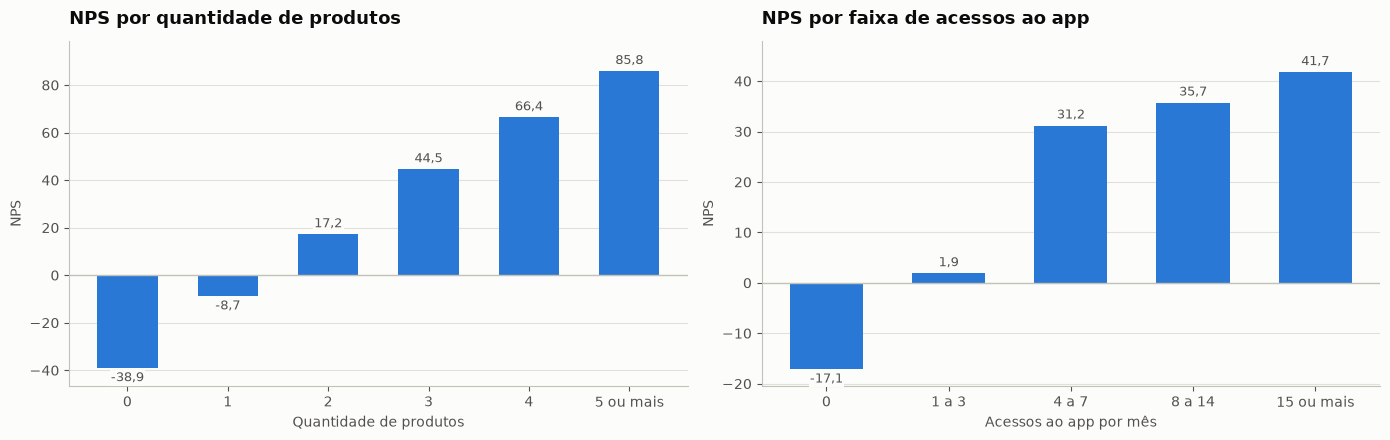

NPS por quantidade de produtos:
              associados   nps
qtd_produtos                  
0                    265 -38.9
1                   1190  -8.7
2                   1696  17.2
3                   1159  44.5
4                    535  66.4
5 ou mais            155  85.8

NPS por faixa de acessos ao app:
                 associados   nps
acessos_app_mes                  
0                       557 -17.1
1 a 3                  1122   1.9
4 a 7                  1300  31.2
8 a 14                 1415  35.7
15 ou mais              606  41.7


In [21]:
faixa_produtos = df["qtd_produtos"].clip(upper=5).map(lambda q: "5 ou mais" if q == 5 else str(q))
nps_produtos = df.groupby(faixa_produtos)["nps_score"].agg(["count", calcular_nps])
nps_produtos.columns = ["associados", "nps"]

faixa_acessos = pd.cut(df["acessos_app_mes"], bins=[-1, 0, 3, 7, 14, np.inf],
                       labels=["0", "1 a 3", "4 a 7", "8 a 14", "15 ou mais"])
nps_acessos = df.groupby(faixa_acessos, observed=True)["nps_score"].agg(["count", calcular_nps])
nps_acessos.columns = ["associados", "nps"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, tabela, nome_x, titulo in [
    (axes[0], nps_produtos, "Quantidade de produtos", "NPS por quantidade de produtos"),
    (axes[1], nps_acessos, "Acessos ao app por mês", "NPS por faixa de acessos ao app"),
]:
    barras = ax.bar(tabela.index.astype(str), tabela["nps"], color=AZUL, width=0.6)
    rotular(ax, barras, [fmt_num(v) for v in tabela["nps"]])
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel(nome_x)
    ax.set_ylabel("NPS")
    ax.set_ylim(min(0, tabela["nps"].min() * 1.2), tabela["nps"].max() * 1.15)
    ax.grid(axis="x", visible=False)
salvar(fig, "11_nps_por_produtos_e_acessos")

print("NPS por quantidade de produtos:")
print(nps_produtos.round(1))
print()
print("NPS por faixa de acessos ao app:")
print(nps_acessos.round(1))

**O que o resultado mostra:**
- **NPS geral de 21,8**, com 43,2% de promotores, 35,4% de neutros e 21,4% de detratores.
- **Agro tem o NPS mais alto (39,5)**, bem acima de Pessoa Jurídica (20,2) e Pessoa Física (17,7).
- Entre os canais, **Digital tem o menor NPS (17,6)**. Esse público é mais jovem e tem menos
  produtos (previdência, por exemplo, é menos comum entre os mais jovens), o que puxa a
  satisfação para baixo.
- Entre os estados, o NPS varia de 18,5 (RS) a 30,0 (MG). RS é o maior estado da base, então o
  NPS mais baixo ali tem peso relevante no resultado geral.
- A relação com a **quantidade de produtos** é a mais forte: o NPS vai de -38,9 entre quem não tem
  nenhum produto para 85,8 entre quem tem 5 ou mais.
- O **uso do app** também acompanha a satisfação: quem não acessou o app no mês tem NPS negativo
  (-17,1), enquanto quem acessa 15 vezes ou mais chega a 41,7.

## 5. Churn

**Pergunta de negócio:** quantos associados a cooperativa está perdendo, em quais segmentos e o
que diferencia quem saiu de quem continua ativo?

**Análise:** taxa de churn (associados Churned sobre o total) geral e por segmento, comparação do
perfil médio de Churned e Ativos e ranking das variáveis que mais separam os dois grupos.

Taxa de churn geral: 14,6%


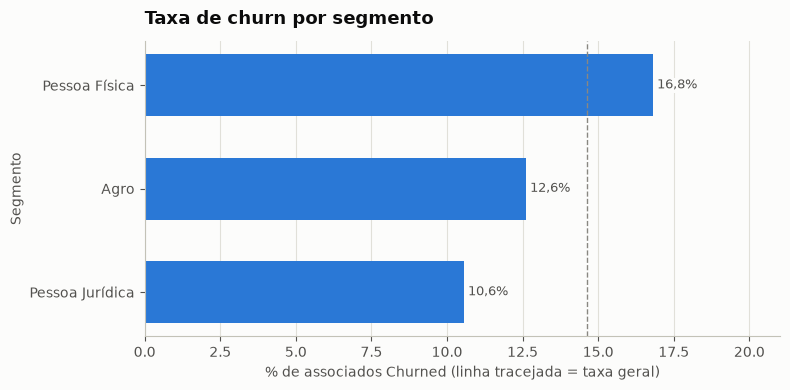

In [22]:
taxa_churn = (df["status"] == "Churned").mean() * 100
print(f"Taxa de churn geral: {fmt_pct(taxa_churn)}")

churn_segmento = (df.groupby("segmento")["status"].apply(lambda s: (s == "Churned").mean()) * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(churn_segmento.index, churn_segmento.values, color=AZUL, height=0.6)
rotular(ax, barras, [fmt_pct(v) for v in churn_segmento.values])
ax.axvline(taxa_churn, color="#898781", linestyle="--", linewidth=1, zorder=1)
ax.set_title("Taxa de churn por segmento")
ax.set_xlabel("% de associados Churned (linha tracejada = taxa geral)")
ax.set_ylabel("Segmento")
ax.set_xlim(0, churn_segmento.max() * 1.25)
ax.grid(axis="y", visible=False)
salvar(fig, "12_churn_por_segmento")

### 5.1 Churn por tempo de associação

Tempo de associação = anos entre a data de associação e 30/09/2025 (fim do período da base).

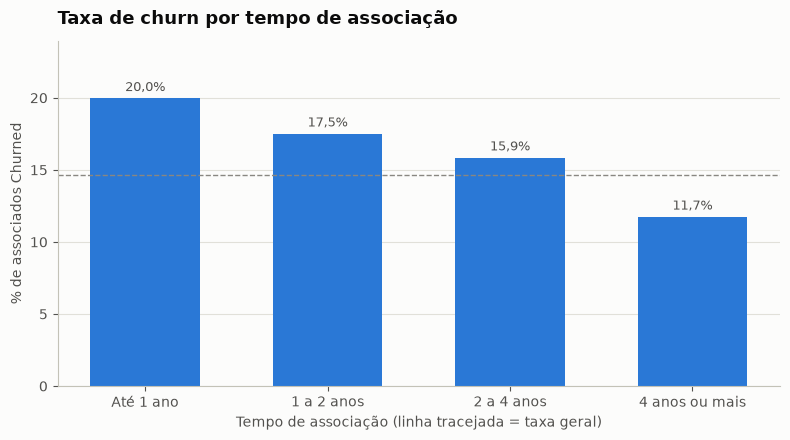

,associados,taxa_churn
tempo_associacao,,
Até 1 ano,661,20.0
1 a 2 anos,651,17.5
2 a 4 anos,1287,15.9
4 anos ou mais,2401,11.7


In [23]:
fim_periodo = pd.Timestamp("2025-09-30")
anos_associacao = (fim_periodo - pd.to_datetime(df["data_associacao"])).dt.days / 365.25
faixa_tempo = pd.cut(anos_associacao, bins=[0, 1, 2, 4, 8],
                     labels=["Até 1 ano", "1 a 2 anos", "2 a 4 anos", "4 anos ou mais"],
                     include_lowest=True).rename("tempo_associacao")
churn_tempo = df.groupby(faixa_tempo, observed=True)["status"].agg(
    associados="count", taxa_churn=lambda s: (s == "Churned").mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(churn_tempo.index.astype(str), churn_tempo["taxa_churn"], color=AZUL, width=0.6)
rotular(ax, barras, [fmt_pct(v) for v in churn_tempo["taxa_churn"]])
ax.axhline(taxa_churn, color="#898781", linestyle="--", linewidth=1, zorder=1)
ax.set_title("Taxa de churn por tempo de associação")
ax.set_xlabel("Tempo de associação (linha tracejada = taxa geral)")
ax.set_ylabel("% de associados Churned")
ax.set_ylim(0, churn_tempo["taxa_churn"].max() * 1.2)
ax.grid(axis="x", visible=False)
salvar(fig, "16_churn_por_tempo_associacao")

churn_tempo.round(1)

### 5.2 Perfil Churned x Ativo

In [24]:
variaveis_perfil = {
    "idade": "Idade",
    "qtd_produtos": "Quantidade de produtos",
    "nps_score": "Nota NPS",
    "dias_desde_ultimo_acesso": "Dias sem acesso",
    "transacoes_ultimo_trimestre": "Transações no trimestre",
}
df["anos_associacao"] = anos_associacao.round(2)
ativos = df[df["status"] == "Ativo"]
churned = df[df["status"] == "Churned"]

perfil = pd.DataFrame({
    "Ativo": ativos[list(variaveis_perfil)].mean(),
    "Churned": churned[list(variaveis_perfil)].mean(),
}).rename(index=variaveis_perfil)
perfil["Diferença (%)"] = (perfil["Churned"] / perfil["Ativo"] - 1) * 100
perfil.round(2)

,Ativo,Churned,Diferença (%)
Idade,41.79,42.73,2.25
Quantidade de produtos,2.44,1.31,-46.22
Nota NPS,8.27,6.69,-19.12
Dias sem acesso,12.08,221.70,1735.76
Transações no trimestre,35.00,2.05,-94.14


### 5.3 Variáveis que mais diferenciam Churned e Ativos

Para comparar variáveis com escalas diferentes, a diferença entre as médias foi dividida pelo
desvio padrão combinado dos dois grupos (diferença padronizada). Valores acima de 0 indicam
média maior entre os Churned; abaixo de 0, média menor.

Observação: "dias sem acesso" aparece muito à frente das demais porque é, em boa parte, consequência
da própria saída do associado (quem saiu deixa de acessar). Ela confirma o churn, mas não ajuda a
antecipá-lo. As variáveis seguintes são mais úteis para prevenção.

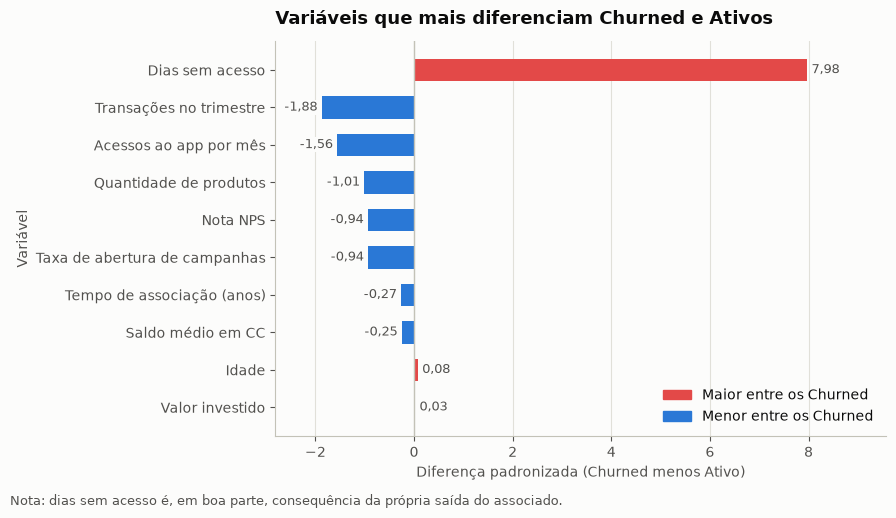

Transações no trimestre         -1.88
Acessos ao app por mês          -1.56
Quantidade de produtos          -1.01
Nota NPS                        -0.94
Taxa de abertura de campanhas   -0.94
Tempo de associação (anos)      -0.27
Saldo médio em CC               -0.25
Valor investido                  0.03
Idade                            0.08
Dias sem acesso                  7.98
dtype: float64

In [25]:
variaveis_diferenca = {
    **variaveis_perfil,
    "acessos_app_mes": "Acessos ao app por mês",
    "saldo_medio_cc": "Saldo médio em CC",
    "valor_investido": "Valor investido",
    "taxa_abertura_campanha": "Taxa de abertura de campanhas",
    "anos_associacao": "Tempo de associação (anos)",
}


def diferenca_padronizada(coluna):
    a, c = ativos[coluna], churned[coluna]
    desvio_combinado = np.sqrt(((len(a) - 1) * a.var() + (len(c) - 1) * c.var()) / (len(a) + len(c) - 2))
    return (c.mean() - a.mean()) / desvio_combinado


diferencas = pd.Series({nome: diferenca_padronizada(col) for col, nome in variaveis_diferenca.items()})
diferencas = diferencas.reindex(diferencas.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(diferencas.index, diferencas.values,
                 color=[VERMELHO if v > 0 else AZUL for v in diferencas.values], height=0.6)
rotular(ax, barras, [fmt_num(v, 2) for v in diferencas.values])
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title("Variáveis que mais diferenciam Churned e Ativos")
ax.set_xlabel("Diferença padronizada (Churned menos Ativo)")
ax.set_ylabel("Variável")
ax.set_xlim(diferencas.min() * 1.5, diferencas.max() * 1.2)
ax.grid(axis="y", visible=False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=VERMELHO), plt.Rectangle((0, 0), 1, 1, color=AZUL)],
          labels=["Maior entre os Churned", "Menor entre os Churned"], loc="lower right", frameon=False)
fig.text(0.01, -0.02, "Nota: dias sem acesso é, em boa parte, consequência da própria saída do associado.",
         fontsize=9, color=TEXTO_SECUNDARIO, ha="left")
salvar(fig, "13_diferencas_churned_ativo")

diferencas.sort_values().round(2)

**O que o resultado mostra:**
- A **taxa de churn geral é de 14,6%**. Pessoa Física tem a maior taxa (16,8%), acima de Agro
  (12,6%) e Pessoa Jurídica (10,6%).
- O churn é maior entre os **associados recentes**: 20,0% para quem tem até 1 ano de casa, contra
  11,7% para quem tem 4 anos ou mais. O primeiro ano é o período mais crítico do relacionamento.
- Os associados Churned tinham, em média, **46% menos produtos** (1,31 contra 2,44) e NPS mais
  baixo (6,69 contra 8,27). Idade, saldo e valor investido praticamente não diferenciam os grupos.
- Depois de dias sem acesso (que é mais consequência do que causa), as variáveis que mais separam
  os grupos são transações e acessos ao app. Elas funcionam como **sinais de alerta**: uma queda
  forte de uso é o momento de agir.
- Quantidade de produtos e NPS são as **alavancas de prevenção**: aumentar a vinculação (mais
  produtos) e tratar detratores reduz o risco antes que o uso caia.

## 6. KPIs de marketing

**Pergunta de negócio:** as campanhas funcionam? Quais segmentos e canais respondem melhor e
onde vale concentrar os próximos esforços?

**Análise:** considerando os associados que receberam pelo menos uma campanha:
- **Taxa de abertura** = total de campanhas abertas / total de campanhas recebidas;
- **Taxa de conversão** = total de campanhas convertidas / total de campanhas abertas;
- **Conversões por 100 campanhas recebidas** = total convertidas / total recebidas × 100
  (efetividade do funil completo).

In [26]:
receberam = df[df["campanhas_recebidas"] > 0]
colunas_campanha = ["campanhas_recebidas", "campanhas_abertas", "campanhas_convertidas"]


def taxas_campanha(coluna):
    somas = receberam.groupby(coluna)[colunas_campanha].sum()
    return pd.DataFrame({
        "associados": receberam.groupby(coluna).size(),
        "taxa_abertura": somas["campanhas_abertas"] / somas["campanhas_recebidas"] * 100,
        "taxa_conversao": somas["campanhas_convertidas"] / somas["campanhas_abertas"] * 100,
        "conversoes_por_100": somas["campanhas_convertidas"] / somas["campanhas_recebidas"] * 100,
    })


def grafico_taxas(tabela, nome_dimensao, metricas, nome_arquivo):
    fig, axes = plt.subplots(1, len(metricas), figsize=(6 * len(metricas), 4.2))
    for ax, (coluna, titulo, rotulo_eixo, sufixo) in zip(axes, metricas):
        valores = tabela[coluna].sort_values()
        barras = ax.barh(valores.index, valores.values, color=AZUL, height=0.6)
        rotular(ax, barras, [fmt_num(v) + sufixo for v in valores.values])
        ax.set_title(titulo)
        ax.set_xlabel(rotulo_eixo)
        ax.set_ylabel(nome_dimensao)
        ax.set_xlim(0, valores.max() * 1.25)
        ax.grid(axis="y", visible=False)
    salvar(fig, nome_arquivo)


print(f"Associados que receberam campanha: {fmt_num(len(receberam), 0)} ({fmt_pct(len(receberam) / len(df) * 100)})")
totais = receberam[colunas_campanha].sum()
print(f"Taxa de abertura geral: {fmt_pct(totais['campanhas_abertas'] / totais['campanhas_recebidas'] * 100)}")
print(f"Taxa de conversão geral: {fmt_pct(totais['campanhas_convertidas'] / totais['campanhas_abertas'] * 100)}")

Associados que receberam campanha: 4.986 (99,7%)
Taxa de abertura geral: 39,9%
Taxa de conversão geral: 15,3%


### 6.1 Abertura e conversão por segmento

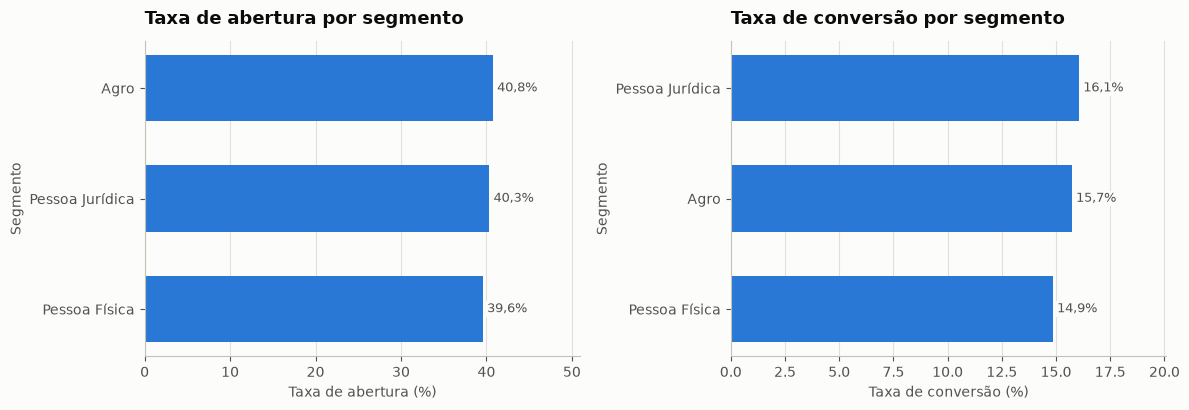

,associados,taxa_abertura,taxa_conversao,conversoes_por_100
segmento,,,,
Agro,788,40.8,15.7,6.4
Pessoa Física,2999,39.6,14.9,5.9
Pessoa Jurídica,1199,40.3,16.1,6.5


In [27]:
campanhas_segmento = taxas_campanha("segmento")
grafico_taxas(campanhas_segmento, "Segmento",
              [("taxa_abertura", "Taxa de abertura por segmento", "Taxa de abertura (%)", "%"),
               ("taxa_conversao", "Taxa de conversão por segmento", "Taxa de conversão (%)", "%")],
              "14_campanhas_por_segmento")
campanhas_segmento.round(1)

### 6.2 Efetividade por canal de aquisição

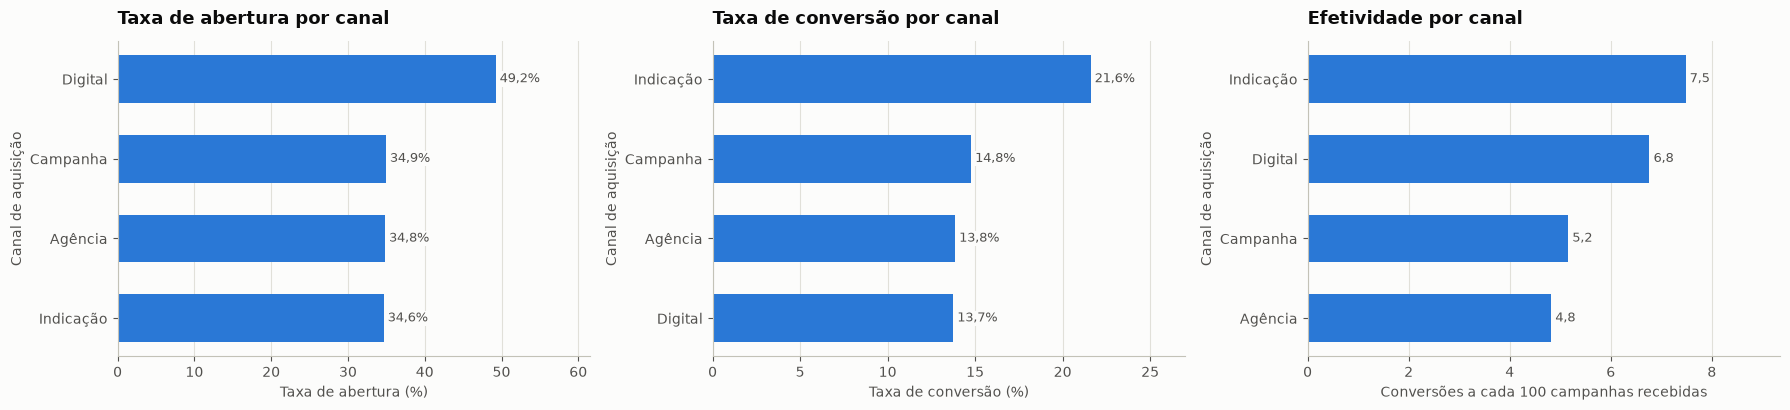

,associados,taxa_abertura,taxa_conversao,conversoes_por_100
canal_aquisicao,,,,
Agência,1427,34.8,13.8,4.8
Campanha,772,34.9,14.8,5.2
Digital,1768,49.2,13.7,6.8
Indicação,1019,34.6,21.6,7.5


In [28]:
campanhas_canal = taxas_campanha("canal_aquisicao")
grafico_taxas(campanhas_canal, "Canal de aquisição",
              [("taxa_abertura", "Taxa de abertura por canal", "Taxa de abertura (%)", "%"),
               ("taxa_conversao", "Taxa de conversão por canal", "Taxa de conversão (%)", "%"),
               ("conversoes_por_100", "Efetividade por canal", "Conversões a cada 100 campanhas recebidas", "")],
              "15_campanhas_por_canal")
campanhas_canal.round(1)

### 6.3 Priorização de segmentos para campanhas

Tabela que junta, por segmento, o tamanho da base ativa, a resposta às campanhas, o risco
(churn e participação na classe RFV "Em risco") e a oportunidade de cartão de crédito.

In [29]:
rfv_segmento = rfv.merge(df[["associado_id", "segmento"]], on="associado_id")
priorizacao = pd.DataFrame({
    "ativos": ativos.groupby("segmento").size(),
    "taxa_churn": churn_segmento,
    "taxa_abertura": campanhas_segmento["taxa_abertura"],
    "taxa_conversao": campanhas_segmento["taxa_conversao"],
    "pct_ativos_em_risco_rfv": rfv_segmento.groupby("segmento")["segmento_rfv"].apply(lambda s: (s == "Em risco").mean() * 100),
    "oportunidade_cartao": oportunidade_segmento["associados"],
    "saldo_medio_cc_ativos": ativos.groupby("segmento")["saldo_medio_cc"].mean(),
}).sort_values("ativos", ascending=False)
priorizacao.round(1)

,ativos,taxa_churn,taxa_abertura,taxa_conversao,pct_ativos_em_risco_rfv,oportunidade_cartao,saldo_medio_cc_ativos
segmento,,,,,,,
Pessoa Física,2039,16.8,39.6,14.9,33.5,552,3651.6
Pessoa Jurídica,880,10.6,40.3,16.1,9.3,264,15884.4
Agro,605,12.6,40.8,15.7,19.0,161,8144.0


**O que o resultado mostra:**
- Praticamente toda a base recebeu campanhas. A **taxa de abertura geral é de 39,9%** e a
  **taxa de conversão é de 15,3%**.
- Entre os segmentos, as taxas são parecidas (abertura de 39,6% a 40,8%, conversão de 14,9% a
  16,1%). O segmento, sozinho, não explica a resposta às campanhas.
- O canal de aquisição faz mais diferença: quem veio pelo **Digital abre mais** (49,2%), mas
  converte menos (13,7%). Quem veio por **Indicação converte mais** (21,6%) e tem a melhor
  efetividade no funil completo (7,5 conversões a cada 100 campanhas, contra 4,8 de quem veio pela
  Agência).

**Recomendação de priorização:**
1. **Pessoa Física: retenção e cross-sell.** É a maior base ativa (2.039), tem o maior churn
   (16,8%), o menor NPS (17,7), 33,5% dos ativos na classe RFV Em risco e 552 associados com conta
   e sem cartão. Prioridade para campanhas de reengajamento e de cartão de crédito.
2. **Pessoa Jurídica: valor.** Tem o maior saldo médio entre os ativos (cerca de R$ 15,9 mil), o
   menor churn (10,6%) e só 9,3% dos ativos na classe Em risco. Campanhas de aprofundamento de
   relacionamento (cartão empresarial, seguro e consórcio), começando pelos 264 sem cartão.
3. **Agro: manutenção.** Já tem mais produtos e o maior NPS (39,5). Campanhas pontuais de
   produtos complementares, de olho nos 19,0% de ativos na classe Em risco.

Em todos os segmentos, vale usar o **Digital como canal de alcance** (maior abertura), estimular
a **Indicação** como fonte de novos associados (maior conversão) e reforçar o relacionamento no
**primeiro ano de associação**, quando o churn é maior.

## 7. Resumo executivo

Principais indicadores da base em uma única tabela.

In [30]:
kpis = pd.DataFrame({
    "Indicador": [
        "Total de associados",
        "Associados ativos",
        "Taxa de churn",
        "NPS geral",
        "Média de produtos por associado",
        "Taxa de abertura de campanhas",
        "Taxa de conversão de campanhas",
        "Saldo médio em CC (associados com conta)",
    ],
    "Valor": [
        fmt_num(len(df), 0),
        f"{fmt_num(len(ativos), 0)} ({fmt_pct(len(ativos) / len(df) * 100)})",
        fmt_pct(taxa_churn),
        fmt_num(nps_geral),
        fmt_num(df["qtd_produtos"].mean(), 2),
        fmt_pct(totais["campanhas_abertas"] / totais["campanhas_recebidas"] * 100),
        fmt_pct(totais["campanhas_convertidas"] / totais["campanhas_abertas"] * 100),
        "R$ " + fmt_num(df.loc[df["tem_conta_corrente"] == 1, "saldo_medio_cc"].mean(), 2),
    ],
})
kpis.style.hide(axis="index")

Indicador,Valor
Total de associados,5.000
Associados ativos,"3.524 (70,5%)"
Taxa de churn,"14,6%"
NPS geral,"21,8"
Média de produtos por associado,"2,20"
Taxa de abertura de campanhas,"39,9%"
Taxa de conversão de campanhas,"15,3%"
Saldo médio em CC (associados com conta),"R$ 8.057,30"


### Principais insights

1. **Mais produtos, mais satisfação e menos churn.** O NPS vai de -38,9 (nenhum produto) a 85,8
   (5 ou mais), e quem saiu tinha 46% menos produtos que os ativos. Aumentar a vinculação é a
   principal alavanca de retenção.
2. **O primeiro ano e a queda de uso são os momentos de risco.** O churn chega a 20,0% entre quem
   tem até 1 ano de casa, contra 11,7% entre quem tem 4 anos ou mais. Queda em transações e
   acessos ao app é o sinal de alerta para agir sobre o grupo RFV Em risco.
3. **Pessoa Física concentra o risco.** O segmento tem o maior churn (16,8%), o menor NPS (17,7) e
   33,5% dos seus ativos na classe Em risco. Deve ser a prioridade das campanhas de retenção.
4. **Há um público pronto para cross-sell.** São 977 associados ativos com conta corrente e sem
   cartão de crédito (30,6% dos ativos com conta). Como o cartão é o produto mais ligado aos
   demais, ele também abre caminho para seguro e consórcio.
5. **O canal muda a resposta às campanhas.** O Digital abre mais (49,2%) e a Indicação converte
   mais (21,6%). Combinar alcance digital com incentivo à indicação melhora o resultado do funil.

> Lembrete: os dados são simulados. Os insights demonstram o método de análise e não representam
> fatos sobre uma instituição real.